# Environment Setup

In [1]:
import sys
import os

# Ensure project root is in path
sys.path.append(os.path.abspath(".."))

# Imports

In [2]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt

import model.assumptions as assumptions_module
import model.policy as policy_module
import model.projection as projection_module
import model.valuation as valuation_module
import model.results as results_module
import model.analysis.profit as profit_analysis

plt.style.use("seaborn-v0_8")

# Reload Modules

In [3]:
def reload_all():

    importlib.reload(assumptions_module)
    importlib.reload(policy_module)
    importlib.reload(projection_module)
    importlib.reload(results_module)
    importlib.reload(valuation_module)
    importlib.reload(profit_analysis)

reload_all()

# Notebook Entry Points 
import model.valuation as valuation 
import model.analysis.profit as profit_analysis 
import model.assumptions as assumptions_module 
import model.policy as policy_module

# Assumptions Setup

In [4]:
mortality = assumptions_module.load_mortality_table(
    "../data/mortality_tables/basic_mortality_table.csv"
)

interest = assumptions_module.FlatYieldCurve(
    interest_rate=0.03
)

lapse_table = assumptions_module.load_lapse_table(
    "../data/lapse_rates.csv"
)

assumptions = assumptions_module.AssumptionSet(
    mortality=mortality,
    interest=interest,
    lapse=lapse_table
)

# Single Policy Setup

In [25]:
policy = policy_module.Policy(
    age=30,
    term=20,
    sum_assured=100000,
    premium=5000,
    smoker_status="Non-Smoker",
    product_type="Term"
)

# Projection Analysis

In [26]:
projection = projection_module.project_cashflows(
    policy,
    assumptions
)

projection

projection.rows[5]

ProjectionRow(t=5, age=35, prob_inforce=0.747587, qx=0.000580)

# Run valuation

In [16]:
valuation_result = valuation_module.value_policy(
    policy,
    assumptions,
    return_breakdown=True
)

# Core results

In [17]:
summary = {
    "PV Premiums": valuation_result.pv_premiums,
    "PV Claims": valuation_result.pv_claims,
    "Net Value": valuation_result.net_value
}

pd.Series(summary)

PV Premiums    54314.284843
PV Claims       1005.052622
Net Value      53309.232221
dtype: float64

# Build Analysis Dataset

In [18]:
df = profit_analysis.build_profit_dataframe(valuation_result)
df = profit_analysis.add_profit_signature(df)

# Profit Emergence Table

In [19]:
df[["t",
    "net_cashflow",
    "cum_cashflow",
    "pv_net",
    "cum_profit"
]].round(2)

,t,net_cashflow,cum_cashflow,pv_net,cum_profit
0,0,4963.00,4963.00,4963.00,4963.00
1,1,4561.36,9524.36,4428.51,9391.51
2,2,4327.98,13852.34,4079.54,13471.04
3,3,4106.36,17958.70,3757.90,17228.94
4,4,3895.13,21853.84,3460.78,20689.72
5,5,3694.57,25548.41,3186.97,23876.69
6,6,3577.25,29125.65,2995.89,26872.58
7,7,3462.72,32588.38,2815.51,29688.09
8,8,3350.93,35939.31,2645.26,32333.35
9,9,3241.82,39181.13,2484.58,34817.93


# Profit Signature

In [20]:
df[["t", "pv_net", "profit_pct"]].round(4)

,t,pv_net,profit_pct
0,0,4963.0000,0.0931
1,1,4428.5095,0.0831
2,2,4079.5352,0.0765
3,3,3757.8999,0.0705
4,4,3460.7751,0.0649
5,5,3186.9719,0.0598
6,6,2995.8867,0.0562
7,7,2815.5090,0.0528
8,8,2645.2577,0.0496
9,9,2484.5837,0.0466


# Summary Metrics

In [21]:
pd.Series(profit_analysis.summary_metrics(df))

total_pv_profit      53309.232221
total_cash_profit    67290.141425
peak_profit_year         0.000000
dtype: float64

# Visualisations

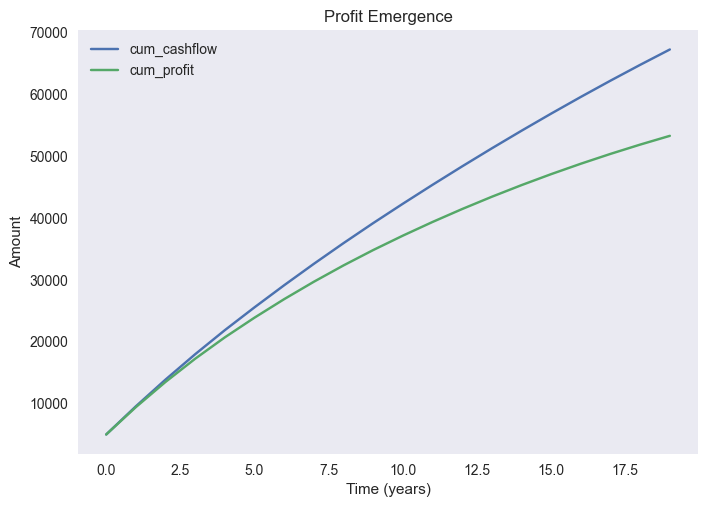

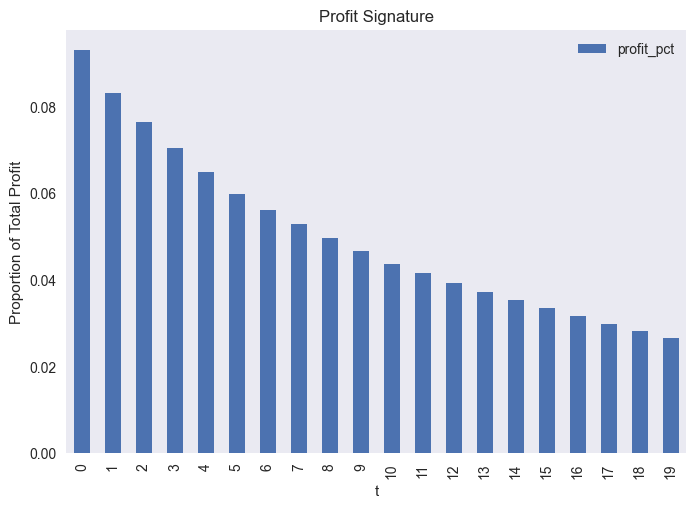

In [22]:
# Profit Emergence

df.plot(x="t", y=["cum_cashflow", "cum_profit"])
plt.title("Profit Emergence")
plt.ylabel("Amount")
plt.xlabel("Time (years)")
plt.grid()
plt.show()


# Profit Signature

df.plot(x="t", y="profit_pct", kind="bar")
plt.title("Profit Signature")
plt.ylabel("Proportion of Total Profit")
plt.grid()
plt.show()